In [ ]:
import sys
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from config.settings import *

In [ ]:
I_points = [10,20,30,40,50]

stat_sim_log = {}
for P_des in [1.3,1.4,1.5]:
    for T_des in [323.15,333.15,343.15]:
        states_dyn = []
        states_stat = []
        print(f"Simulating for RHC={0.5}, P_des={P_des} bar, T_des={T_des} K...")
        for I_LOAD in I_points:
            # --------------- Steady-state Simulation  --------------- #
            operating_inputs_stat = operating_inputs.copy()
            Wout_c = 20 + I_LOAD * 1.
            Win_c = 10 + I_LOAD *1.8
            operating_inputs_stat = {'Tfc': T_des, 'Phi_a_des': 0.0, 'Phi_c_des': 0.5,
                                                    'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                    'Win_c': Win_c, 'Wout_c': Wout_c, 'Win_a': 4.8, 'Wout_a': 4.8}
            model = PEMFC_stat(parameters,operating_inputs_stat)
            sol = model.solve(I_LOAD/parameters['Aact'])
            # --------------- Log states for steady-state simulation  --------------- #
            states_stat.append(sol)
        
        # --------------- Log states for both simulations  --------------- #
        stat_sim_log["RHA"+str(0)+"/RHC" + str(0.5) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

Simulating for RHC=0.5, P_des=1.3 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=343.15 K...


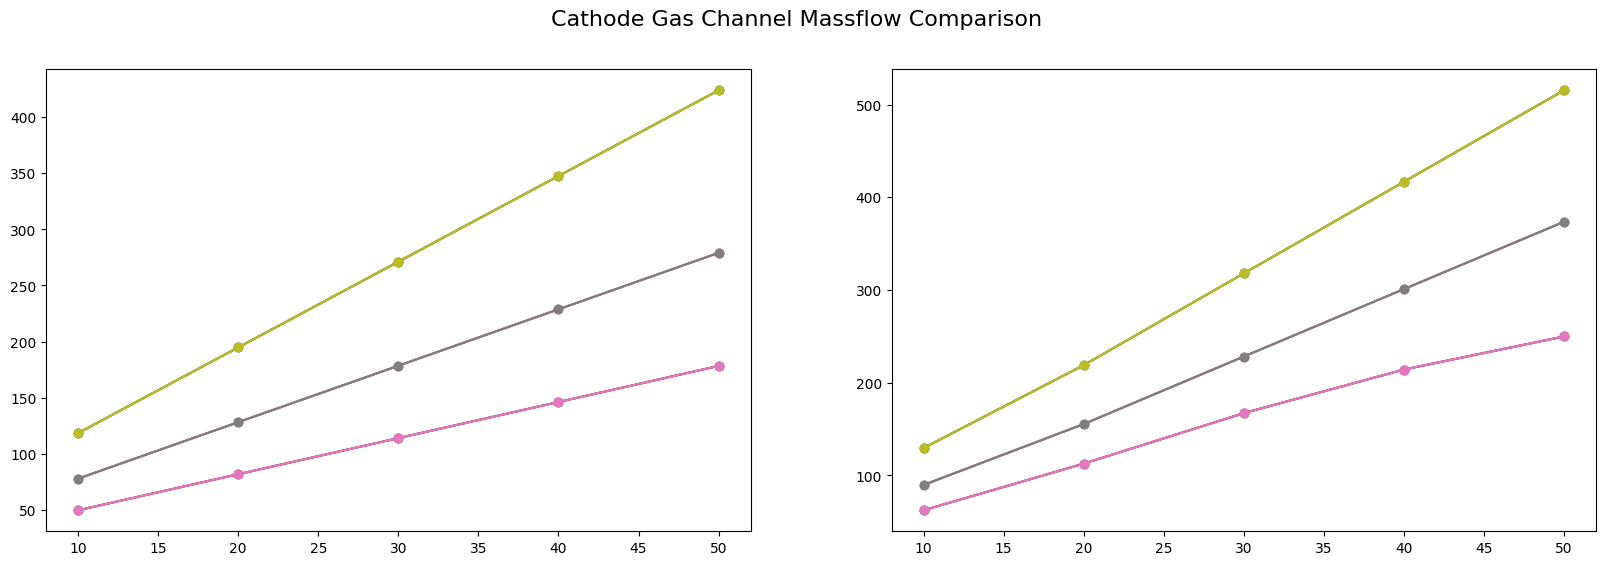

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
fig.suptitle("Cathode Gas Channel Massflow Comparison", fontsize=16)

# DEB_H2O [NL/min] → mol/(m³·s)
# NL/min → m³/s: ×1e-3/60 ; m³/s → mol/s: ÷Vm_STP ; mol/s → mol/(m³·s): ÷V_gc_total
Vm_STP = R * 273.15 / 101325  # m³/mol at standard conditions (0°C, 1 atm)
V_gc_total = n_cell * parameters["Hgc"] * parameters["Wgc"] * parameters["Lgc"]
conv_DEB_H2O = 1e-3 / 60 / Vm_STP / V_gc_total  # (mol/m³/s) per (NL/min)

for key in stat_sim_log.keys():
    states_stat = stat_sim_log[key]["states"]
    # Dynamic vs static model results
    axes[0].plot(I_points, [states["Jv_c_in"] for states in states_stat], label=key, marker='o')
    axes[1].plot(I_points, [states["Jv_c_out"] for states in states_stat], label=key, marker='o')

### Steady-State Results
- **$\lambda_{acl}$ / $\lambda_{ccl}$**: Water content at the anode / cathode catalyst layer
- **$C_{v,acl}$ / $C_{v,ccl}$**: Vapor concentration at the anode / cathode catalyst layer (mol/m³)
- **$J_{w,an}$ / $J_{w,ca}$**: Water flux in the anode / cathode GDL (mol/m²s)
- **$s_{agdl}$ / $s_{cgdl}$**: Saturation profile in the anode / cathode GDL, with vertical dashed lines at the saturation front ($x_{front}$)

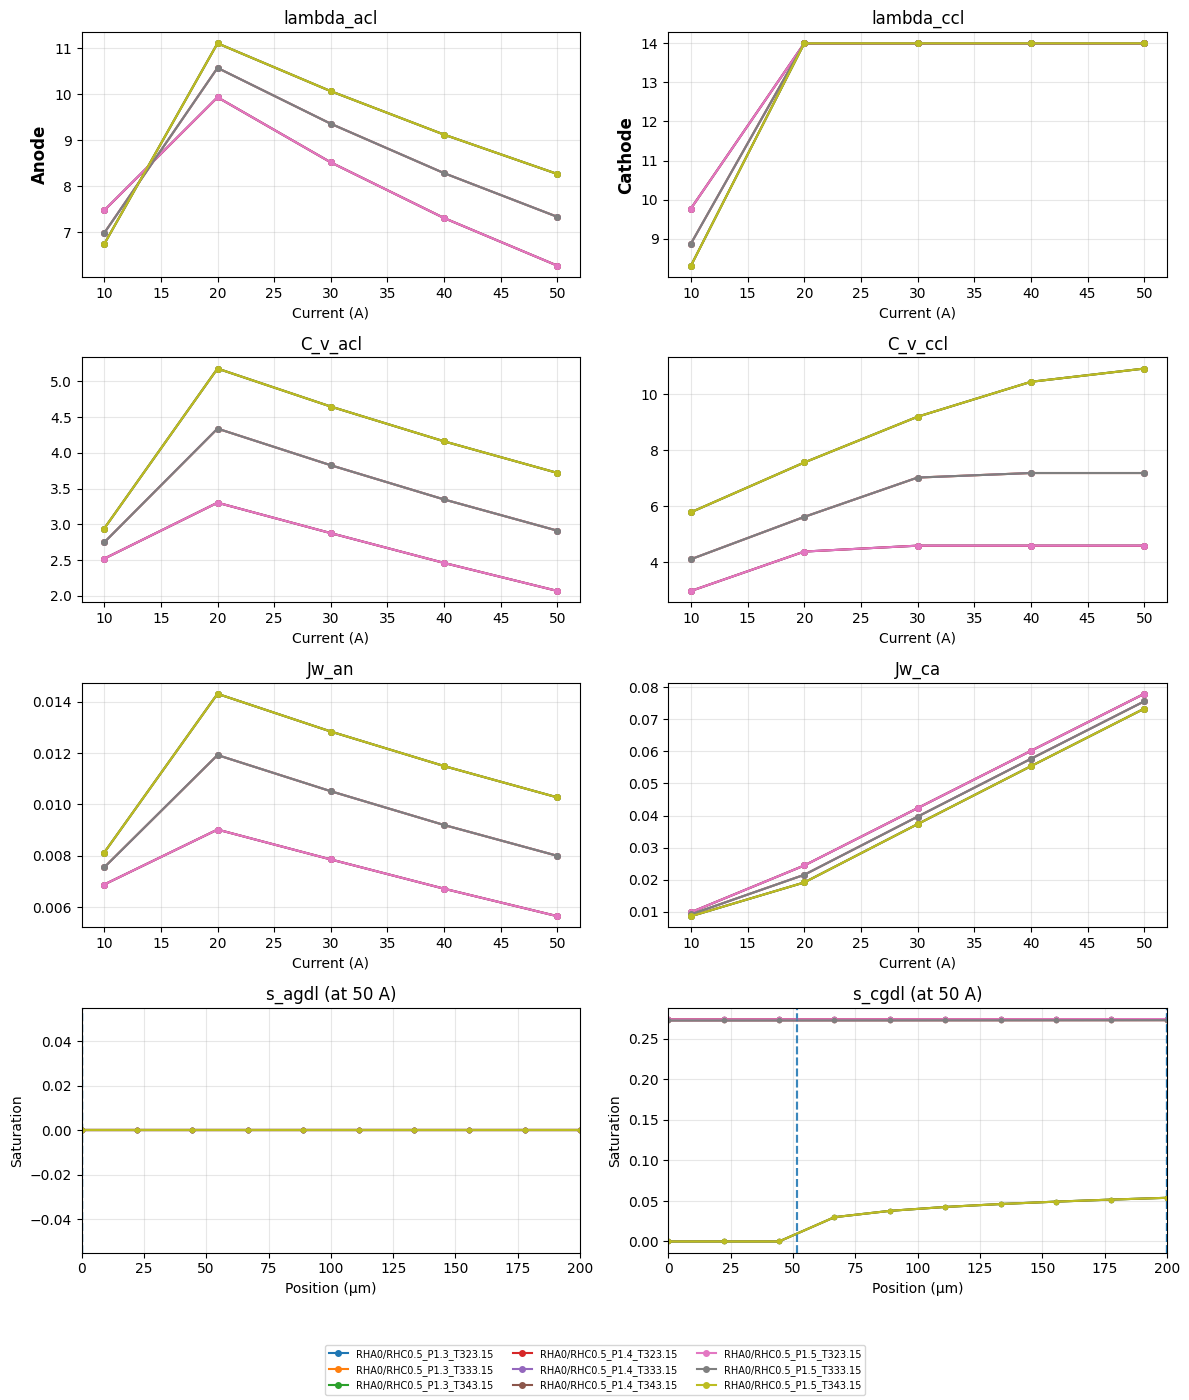

In [ ]:
anode_keys = ["lambda_acl", "C_v_acl", "Jw_an"]
cathode_keys = ["lambda_ccl", "C_v_ccl", "Jw_ca"]

nrows = len(anode_keys) + 1  # extra row for GDL saturation profiles
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 3.5 * nrows))

# Scalar states vs current
for row, (a_key, c_key) in enumerate(zip(anode_keys, cathode_keys)):
    for cond_name, cond_data in stat_sim_log.items():
        a_vals = [sol[a_key] for sol in cond_data["states"]]
        c_vals = [sol[c_key] for sol in cond_data["states"]]
        axes[row, 0].plot(I_points, a_vals, marker='o', markersize=4, label=cond_name)
        axes[row, 1].plot(I_points, c_vals, marker='o', markersize=4, label=cond_name)
    axes[row, 0].set_title(a_key)
    axes[row, 1].set_title(c_key)
    axes[row, 0].set_xlabel("Current (A)")
    axes[row, 1].set_xlabel("Current (A)")
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 1].grid(True, alpha=0.3)

# GDL saturation profiles at max current with s_front vertical lines
x_gdl = np.linspace(0, parameters["Hgdl"] * 1e6, 10)
i_max = I_points[-1]
for cond_name, cond_data in stat_sim_log.items():
    sol = cond_data["states"][-1]  # last load point
    axes[-1, 0].plot(x_gdl, sol["s_agdl"], marker='o', markersize=3, label=cond_name)
    axes[-1, 0].axvline(x=sol["s_front_agdl"] * 1e6, linestyle='--', alpha=0.5)
    axes[-1, 1].plot(x_gdl, sol["s_cgdl"], marker='o', markersize=3, label=cond_name)
    axes[-1, 1].axvline(x=sol["s_front_cgdl"] * 1e6, linestyle='--', alpha=0.5)

axes[-1, 0].set_title(f"s_agdl (at {i_max} A)")
axes[-1, 1].set_title(f"s_cgdl (at {i_max} A)")
axes[-1, 0].set_xlabel("Position (µm)")
axes[-1, 1].set_xlabel("Position (µm)")
axes[-1, 0].set_ylabel("Saturation")
axes[-1, 1].set_ylabel("Saturation")
axes[-1, 0].set_xlim(x_gdl[0], x_gdl[-1])
axes[-1, 1].set_xlim(x_gdl[0], x_gdl[-1])
axes[-1, 0].grid(True, alpha=0.3)
axes[-1, 1].grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Anode", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Cathode", fontsize=12, fontweight='bold')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', fontsize=7, ncol=3)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

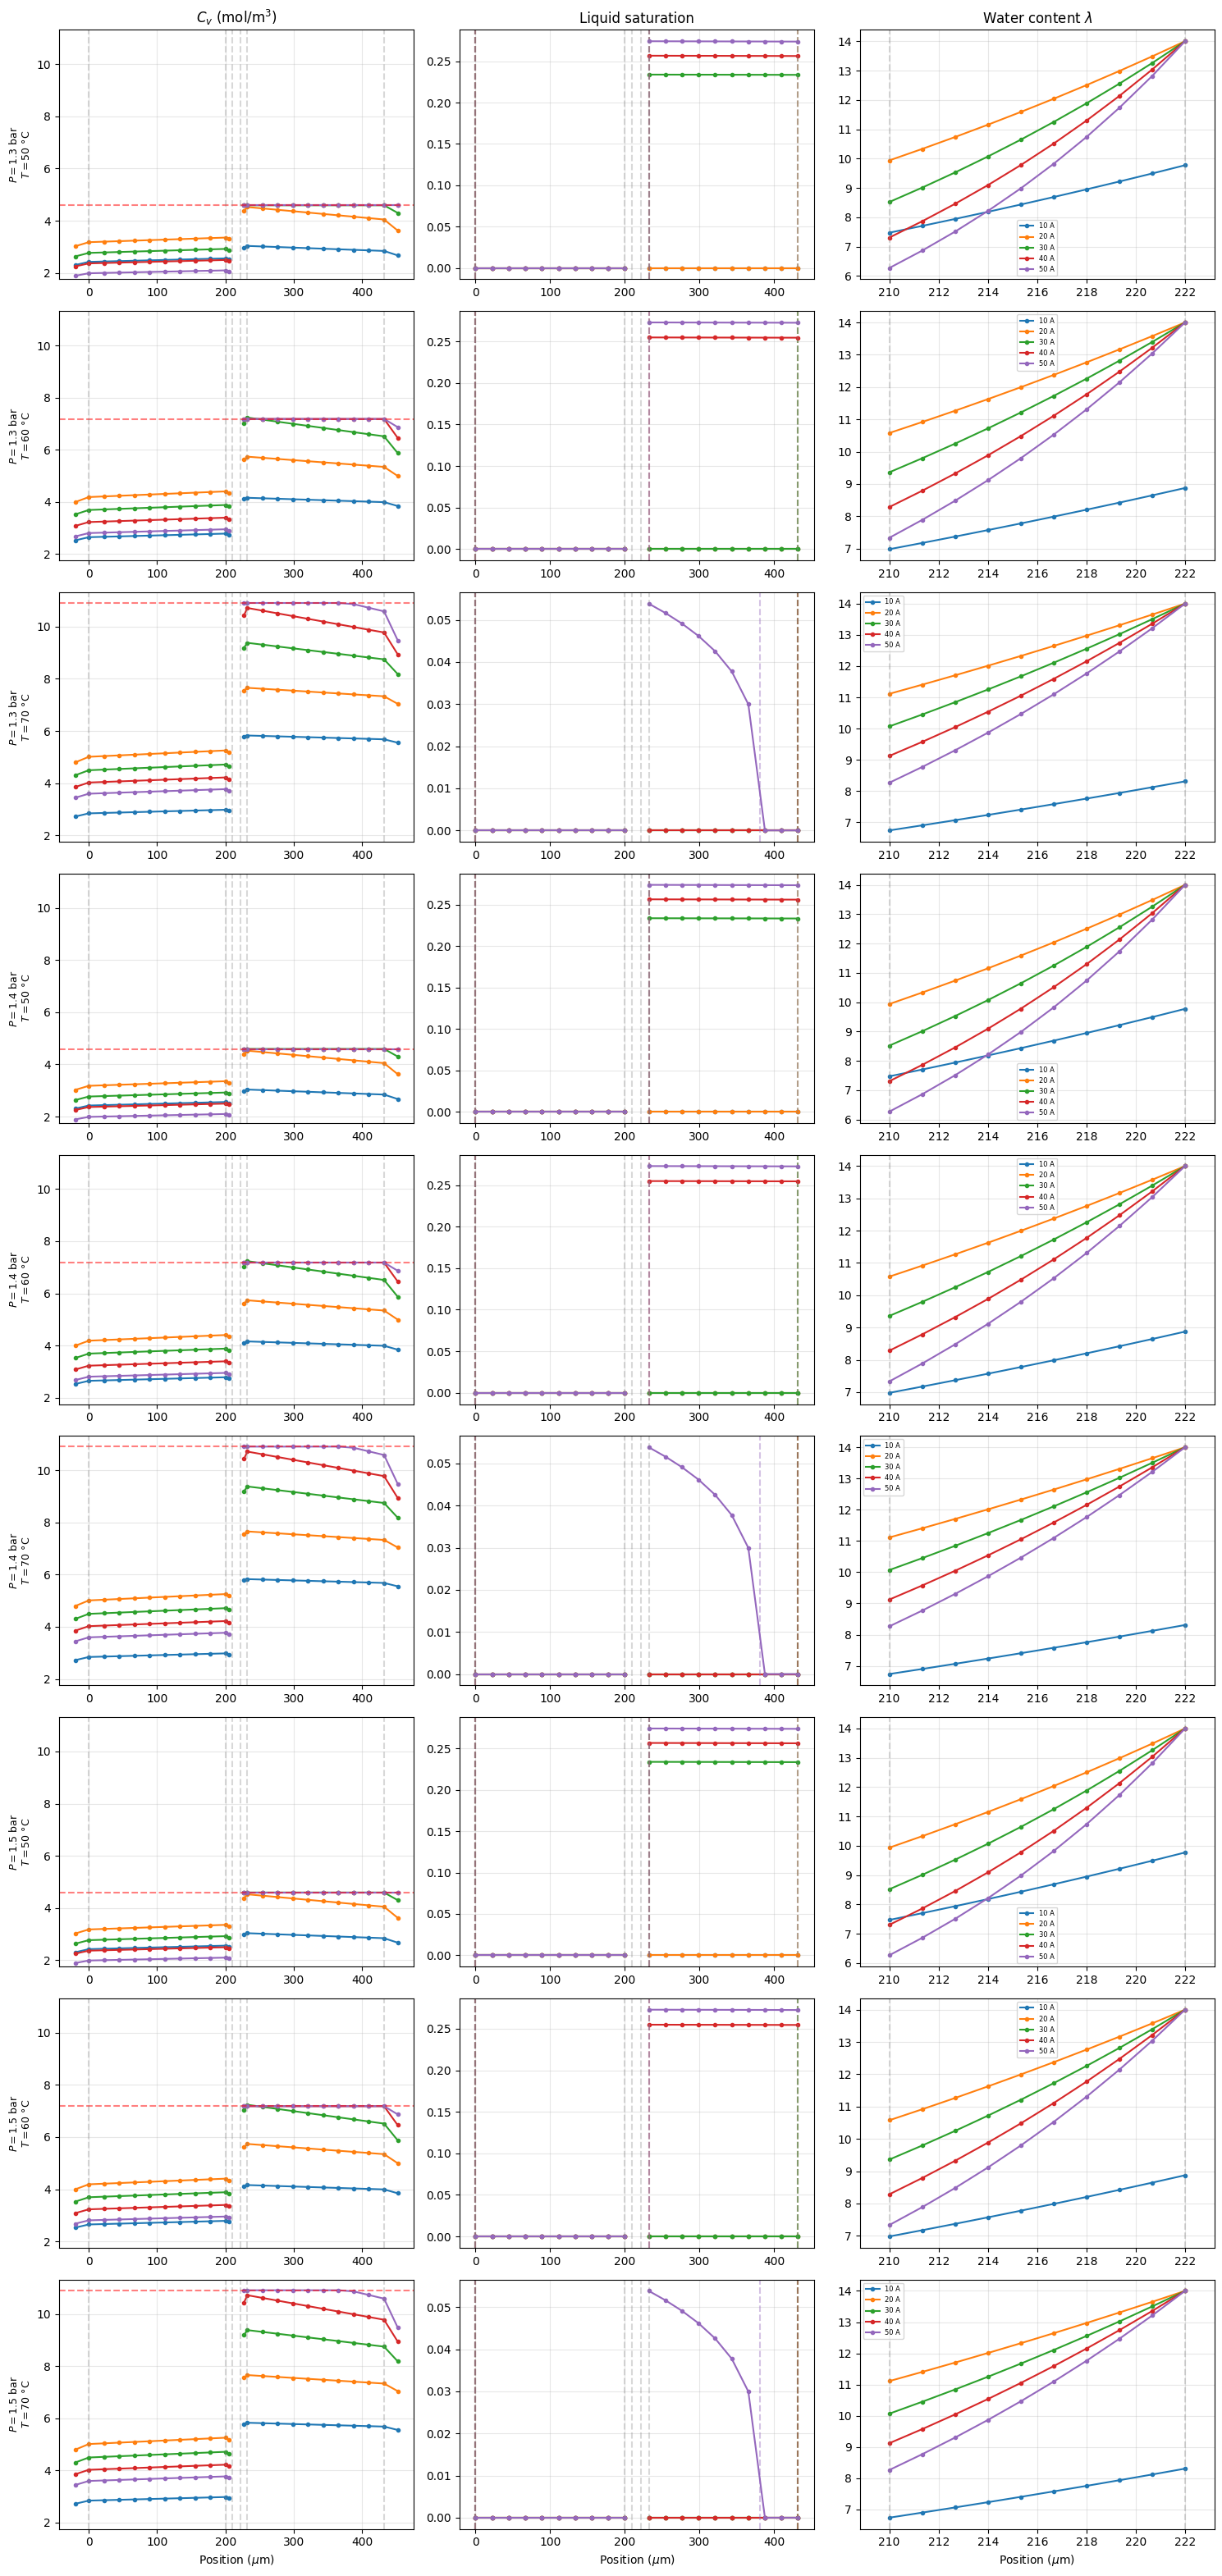

In [ ]:
## 1D Profile plot
cond_keys = list(stat_sim_log.keys())
n_conds = len(cond_keys)

# Parse condition keys into readable labels
def parse_cond_label(key):
    P = float(key.split("_P")[1].split("_T")[0])
    T = float(key.split("_T")[1]) - 273.15
    return f"$P = {P}$ bar\n$T = {T:.0f}$ °C"

# Node positions (µm) — split anode/cathode for vapor & saturation
vp_pos = np.array([nodes[i+1] for i, pf in enumerate(nodes_postfix) if has_species_value("v", pf)]) * 1e6
sat_pos = np.array([nodes[i+1] for i, pf in enumerate(nodes_postfix) if has_species_value("saturation", pf)]) * 1e6
lam_pos = np.array([nodes[i+1] for i, pf in enumerate(nodes_postfix) if has_species_value("lambda", pf)]) * 1e6
lam_pos_mem = lam_pos[1:-1]  # membrane nodes only (exclude acl & ccl)

# Add agc/cgc positions for vapor
agc_pos = nodes[0] * 1e6
cgc_pos = nodes[-1] * 1e6
vp_pos_an = np.concatenate([[agc_pos], vp_pos[:n_gdl + 1]])  # agc + agdl + acl
vp_pos_ca = np.concatenate([vp_pos[n_gdl + 1:], [cgc_pos]])  # ccl + cgdl + cgc

n_an = n_gdl + 1  # agdl + acl
sat_pos_agdl = sat_pos[:n_gdl]  # GDL nodes only
sat_pos_cgdl = sat_pos[n_an + 1:]  # GDL nodes only (skip acl & ccl)

fig, axes = plt.subplots(n_conds, 3, figsize=(15, 3.5 * n_conds))

for row, cond_key in enumerate(cond_keys):
    states = stat_sim_log[cond_key]["states"]
    for sol, I in zip(states, I_points):
        # Vapor — anode & cathode separately with GC nodes
        vp_an = [sol["C_v_agc"]] + list(sol["C_v_agdl"]) + [sol["C_v_acl"]]
        vp_ca = [sol["C_v_ccl"]] + list(sol["C_v_cgdl"][::-1]) + [sol["C_v_cgc"]]
        line, = axes[row, 0].plot(vp_pos_an, vp_an, '-o', markersize=3, label=f"{I} A")
        axes[row, 0].plot(vp_pos_ca, vp_ca, '-o', markersize=3, color=line.get_color())

        # Saturation — GDL only (no CL)
        sat_agdl = list(sol["s_agdl"])
        sat_cgdl = list(sol["s_cgdl"][::-1])
        line2, = axes[row, 1].plot(sat_pos_agdl, sat_agdl, '-o', markersize=3, label=f"{I} A")
        axes[row, 1].plot(sat_pos_cgdl, sat_cgdl, '-o', markersize=3, color=line2.get_color())
        # x_front lines (cathode flipped: GC is on the right)
        axes[row, 1].axvline(x=sol["s_front_agdl"] * 1e6, color=line2.get_color(), linestyle='--', alpha=0.4)
        axes[row, 1].axvline(x=(borders[6] - sol["s_front_cgdl"]) * 1e6, color=line2.get_color(), linestyle='--', alpha=0.4)

        # Lambda — membrane only (no acl/ccl)
        lam = sol["lambda_mem"][::-1]
        axes[row, 2].plot(lam_pos_mem, lam, '-o', markersize=3, label=f"{I} A")

    # Saturation concentration line for vapor plot
    T_cond = float(cond_key.split("_T")[1])
    axes[row, 0].axhline(y=C_v_sat(T_cond), color='red', linestyle='--', alpha=0.5, label='$C_{v,sat}$' if row == 0 else None)

    # Readable condition label on the left
    axes[row, 0].set_ylabel(parse_cond_label(cond_key), fontsize=9)

    # Vapor unit
    if row == 0:
        axes[row, 0].set_title(r"$C_v$ (mol/m$^3$)")

    # Borders for vapor & saturation columns
    for col in range(2):
        if row == 0 and col == 1:
            axes[row, col].set_title("Liquid saturation")
        for b in borders[1:-1]:
            axes[row, col].axvline(x=b*1e6, color='gray', linestyle='--', alpha=0.3)
        axes[row, col].grid(True, alpha=0.3)
        if row == n_conds - 1:
            axes[row, col].set_xlabel(r"Position ($\mu$m)")
    # Lambda column — membrane region with margin
    if row == 0:
        axes[row, 2].set_title(r"Water content $\lambda$")
    margin = (borders[4] - borders[3]) * 0.1 * 1e6
    axes[row, 2].set_xlim(borders[3]*1e6 - margin, borders[4]*1e6 + margin)
    axes[row, 2].axvline(x=borders[3]*1e6, color='gray', linestyle='--', alpha=0.3)
    axes[row, 2].axvline(x=borders[4]*1e6, color='gray', linestyle='--', alpha=0.3)
    axes[row, 2].grid(True, alpha=0.3)
    axes[row, 2].legend(fontsize=6)
    if row == n_conds - 1:
        axes[row, 2].set_xlabel(r"Position ($\mu$m)")

cv_ylims = [axes[row, 0].get_ylim() for row in range(n_conds)]
cv_ymin = min(ylim[0] for ylim in cv_ylims)
cv_ymax = max(ylim[1] for ylim in cv_ylims)
for row in range(n_conds):
    axes[row, 0].set_ylim(cv_ymin, cv_ymax)

plt.tight_layout()
plt.show()

In [ ]:
for sol, I in zip(states, I_points):
    print(f"Current: {I} A, Rohm: {sol['Rohm']} Ohm")

Current: 10 A, Rohm: 2.318452090215779e-06 Ohm
Current: 20 A, Rohm: 1.4345116770630238e-06 Ohm
Current: 30 A, Rohm: 1.5033570535398556e-06 Ohm
Current: 40 A, Rohm: 1.578036426320651e-06 Ohm
Current: 50 A, Rohm: 1.659253512553579e-06 Ohm
